# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Nguyễn Bá Quốc Long"  # TODO: Họ và tên
STUDENT_ID = "2550137"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Bá Quốc Long (2550137)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /Users/nguyenbaquoclong/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [ ]:
# TODO N1
# stable softmax per row
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)
print(shifted_logits.round(2))
print(class_probabilities.round(2))
print(predicted_classes.round(2))
print(confidence_scores.round(2))

[[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
[[0.66 0.24 0.1 ]
 [0.24 0.67 0.09]
 [0.01 0.02 0.98]
 [0.33 0.33 0.33]]
[0 1 2 0]
[0.66 0.67 0.98 0.33]


In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - X_val.mean(axis=0)) / (X_val.std(axis=0))
print(train_feature_mean.round(2))
print(train_feature_std.round(2))
print(X_train_scaled.round(2))
print(X_val_scaled.round(2))

[172.5   69.17   1.65  28.17]
[ 7.48 13.04  0.79  7.65]
[[-0.33 -0.32 -0.57 -0.81]
 [ 1.    0.83  0.95  0.89]
 [-1.67 -1.47 -1.07 -1.2 ]
 [ 0.33  0.06 -0.19 -0.02]
 [-0.6  -0.7  -0.82 -0.54]
 [ 1.27  1.6   1.71  1.68]]
[[-1. -1. -1. -1.]
 [ 1.  1.  1.  1.]]


In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores > confidence_threshold
review_mask = ~correct_mask | ~high_confidence_mask
review_indices = [i for i, should_review in enumerate(review_mask) if should_review]
print(correct_mask)
print(high_confidence_mask)
print(review_mask)
print(review_indices)

[ True False  True False]
[False False  True False]
[ True  True False  True]
[0, 1, 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype('float32')/255.0
print(normalized_batch)
augmented_batch = normalized_batch[:,:,::-1,:].copy()
augmented_batch[0, 0, 0, 0] = 1.0
print(augmented_batch)


[[[[0.         0.00392157 0.00784314]
   [0.01176471 0.01568628 0.01960784]
   [0.02352941 0.02745098 0.03137255]
   [0.03529412 0.03921569 0.04313726]]

  [[0.04705882 0.05098039 0.05490196]
   [0.05882353 0.0627451  0.06666667]
   [0.07058824 0.07450981 0.07843138]
   [0.08235294 0.08627451 0.09019608]]

  [[0.09411765 0.09803922 0.10196079]
   [0.10588235 0.10980392 0.11372549]
   [0.11764706 0.12156863 0.1254902 ]
   [0.12941177 0.13333334 0.13725491]]

  [[0.14117648 0.14509805 0.14901961]
   [0.15294118 0.15686275 0.16078432]
   [0.16470589 0.16862746 0.17254902]
   [0.1764706  0.18039216 0.18431373]]]


 [[[0.1882353  0.19215687 0.19607843]
   [0.2        0.20392157 0.20784314]
   [0.21176471 0.21568628 0.21960784]
   [0.22352941 0.22745098 0.23137255]]

  [[0.23529412 0.23921569 0.24313726]
   [0.24705882 0.2509804  0.25490198]
   [0.25882354 0.2627451  0.26666668]
   [0.27058825 0.27450982 0.2784314 ]]

  [[0.28235295 0.28627452 0.2901961 ]
   [0.29411766 0.29803923 0.3019608 

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Missing value trong CSV được giữ dưới dạng ký hiệu `?`.
3. Symboling có ý nghĩa là đánh giá rủi ro bảo hiểm của mỗi mẫu xe.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum()
display(raw_df)
print('Shape:',raw_shape)
print('Missing info counts:')
print(raw_missing_marker_count)

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


Shape: (205, 26)
Missing info counts:
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")
missing_by_column = df_clean.isna().sum()
display(df_clean)
print('Missing info counts:')
print(missing_by_column)

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


Missing info counts:
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

- Không nên fill tất cả numeric columns bằng cùng một giá trị vì những giá trị tại mỗi cột có thể hoàn toàn khác với những cột còn lại của dữ liệu nên mỗi cột có đặc trưng và ý nghĩa riêng. Việc fill như thế sẽ làm mất đi đặc trưng của mỗi cột.
- Với `price`, lựa chọn fill sẽ phù hợp cho bài EDA vì chỉ có 4 missing values, chiếm tỉ lệ nhỏ so với số mẫu xe là 205, và `price` cũng đóng vai trò quan trọng trong bộ dữ liệu.
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác, điều này khiến cho các thống kê (mean, median, std, ...) của cột sẽ không bao quát được toàn bộ các mẫu xe. Nếu ta xóa các dòng có missing value trong cột này, ta sẽ mất đi nhiều dữ liệu và giảm kích thước dataset, làm ảnh hưởng tới độ tin cậy của phân tích.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean.dropna(subset = AUTO_FEATURES)
display(analysis_df)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype='float64')
print(X_auto)
auto_feature_mean = X_auto.mean(axis=0)
print(auto_feature_mean.round(2))
auto_feature_std = X_auto.std(axis=0)
print(auto_feature_std.round(2))
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std
print(X_auto_scaled.round(2))

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


[[2.5480e+03 1.3000e+02 1.1100e+02 2.1000e+01 2.7000e+01 1.3495e+04]
 [2.5480e+03 1.3000e+02 1.1100e+02 2.1000e+01 2.7000e+01 1.6500e+04]
 [2.8230e+03 1.5200e+02 1.5400e+02 1.9000e+01 2.6000e+01 1.6500e+04]
 ...
 [3.0120e+03 1.7300e+02 1.3400e+02 1.8000e+01 2.3000e+01 2.1485e+04]
 [3.2170e+03 1.4500e+02 1.0600e+02 2.6000e+01 2.7000e+01 2.2470e+04]
 [3.0620e+03 1.4100e+02 1.1400e+02 1.9000e+01 2.5000e+01 2.2625e+04]]
[ 2556.03   126.82   103.4     25.2     30.68 13243.43]
[5.18550e+02 4.16500e+01 3.74600e+01 6.44000e+00 6.83000e+00 7.95864e+03]
[[-0.02  0.08  0.2  -0.65 -0.54  0.03]
 [-0.02  0.08  0.2  -0.65 -0.54  0.41]
 [ 0.51  0.6   1.35 -0.96 -0.69  0.41]
 ...
 [ 0.88  1.11  0.82 -1.12 -1.12  1.04]
 [ 1.27  0.44  0.07  0.12 -0.54  1.16]
 [ 0.98  0.34  0.28 -0.96 -0.83  1.18]]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [ ]:
# TODO D4
price_index = analysis_df['price']
price_z = (price_index - price_index.mean(axis=0)) / price_index.std(axis=0)
print(price_z.round(2))
price_outlier_mask = np.abs(price_z) > 2
price_outliers = price_z[price_outlier_mask]
print(price_outliers.round(2))

0      0.03
1      0.41
2      0.41
3      0.09
4      0.53
       ... 
200    0.45
201    0.73
202    1.03
203    1.16
204    1.18
Name: price, Length: 199, dtype: float64

15     2.20
16     3.52
17     2.96
47     2.38
48     2.80
49     2.85
70     2.30
71     2.62
72     2.73
73     3.47
74     4.03
126    2.42
127    2.61
128    2.98
Name: price, dtype: float64

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

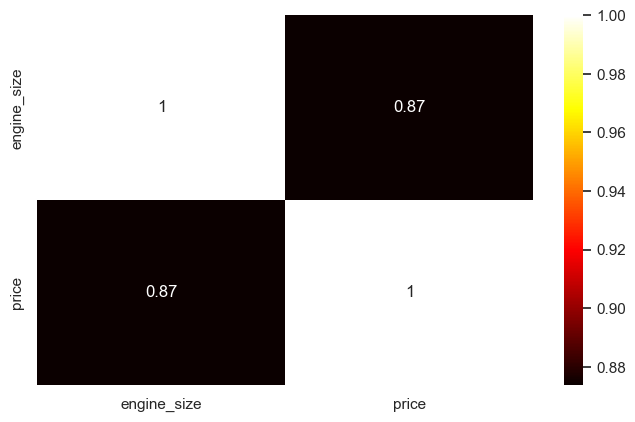

,price_mean
body_style,
convertible,21890.50
hardtop,22208.50
hatchback,9957.44
sedan,14459.76
wagon,12371.96


In [19]:
# TODO D5
engine_price_corr = analysis_df[['engine_size', 'price']].corr()
sns.heatmap(engine_price_corr, annot=True, cmap = 'hot')
plt.show()
price_by_body_style = df_clean.groupby('body_style', observed = True).agg(price_mean = ('price', 'mean')).round(2)
display(price_by_body_style)

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

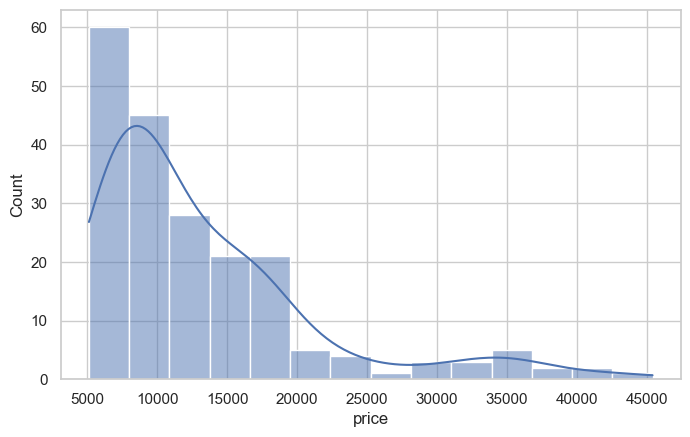

In [20]:
# TODO M2.1: histogram/KDE của price
sns.histplot(df_clean['price'], kde= True)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Đường KDE có đỉnh cao nhất tại mức giá khoảng 5000-10000. Đồ thị lệch phải, các xe chủ yếu có mức giá từ 5000-20000, rất ít xe có mức giá cao từ 20000 trở lên.

## M2.2 Dataset có cân bằng theo body style không?

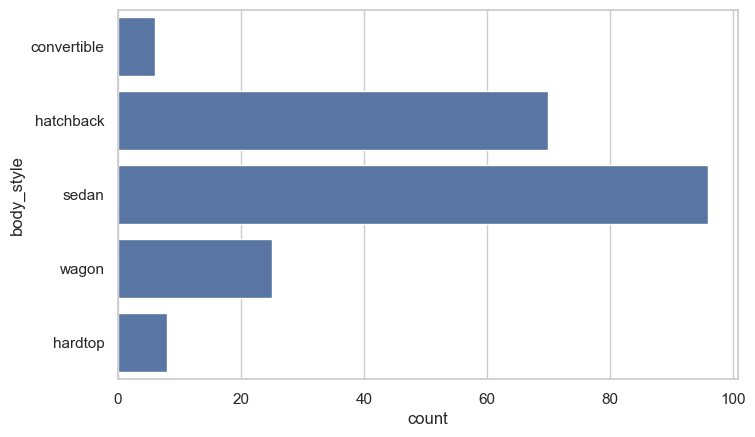

In [21]:
# TODO M2.2: countplot của body_style
sns.countplot(df_clean['body_style'])
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Dựa vào đồ thị, ta thấy nhóm sedan chiếm hơn 4 lần và nhóm hatchback chiếm hơn 3 lần so với convertible, wagon và hardtop. Vì vậy, dataset không cân bằng theo body_style.

## M2.3 Price khác nhau theo body style ra sao?

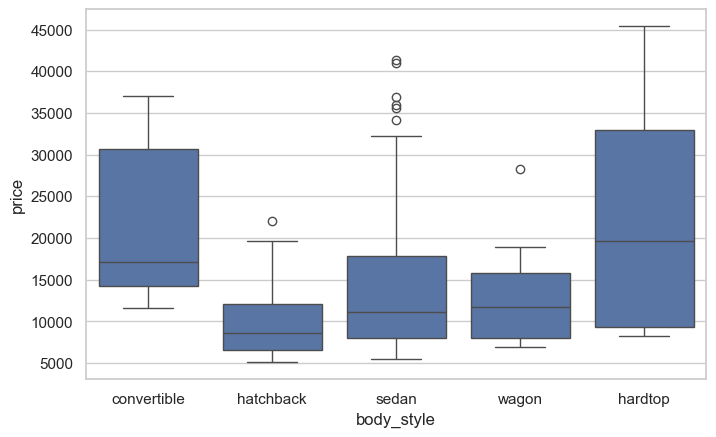

In [22]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(y = df_clean['price'], x = df_clean['body_style'])
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

- Ta thấy cả 5 hộp đều lệch trên và có khoảng cách giữa Q1 và min nhỏ hơn đáng kể so với Q3 và max.
- Nhóm sedan thì có khoảng cách giữa Q3 và max lớn nhất cũng như có outlier lớn nhất, nhóm hardtop độ phân tán dữ liệu trong hộp lớn nhất.

## M2.4 Engine size liên quan thế nào tới price?

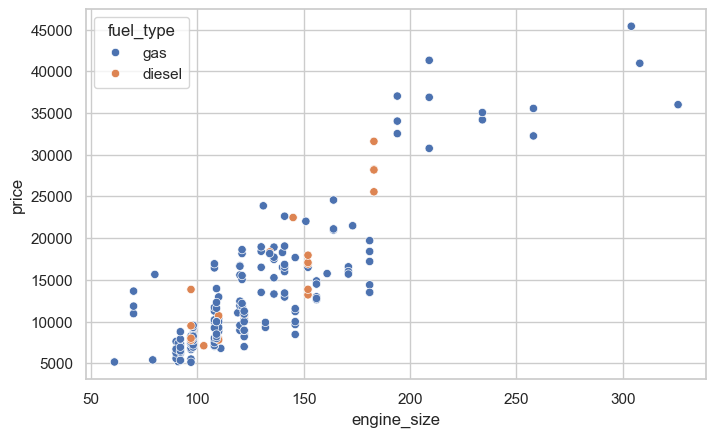

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(df_clean, x = 'engine_size', y = 'price', hue = 'fuel_type')
plt.show()


**Nhận xét:** <!-- 1--2 câu -->

- Khi engine size đi lên thì price đi lên một cách tuyến tính.
- Các xe chạy bằng gas chiếm đa số và trải dài từ 60-300 trong khi xe chạy bằng diesel thì chia ra ba cụm rõ rệt (100 - 150 - 180) với những xe có kích cỡ động cơ 180 có mức giá cao hơn so với những mẫu xe bằng gas có kích cỡ tương tự.

## M2.5 Các feature numeric tương quan ra sao?

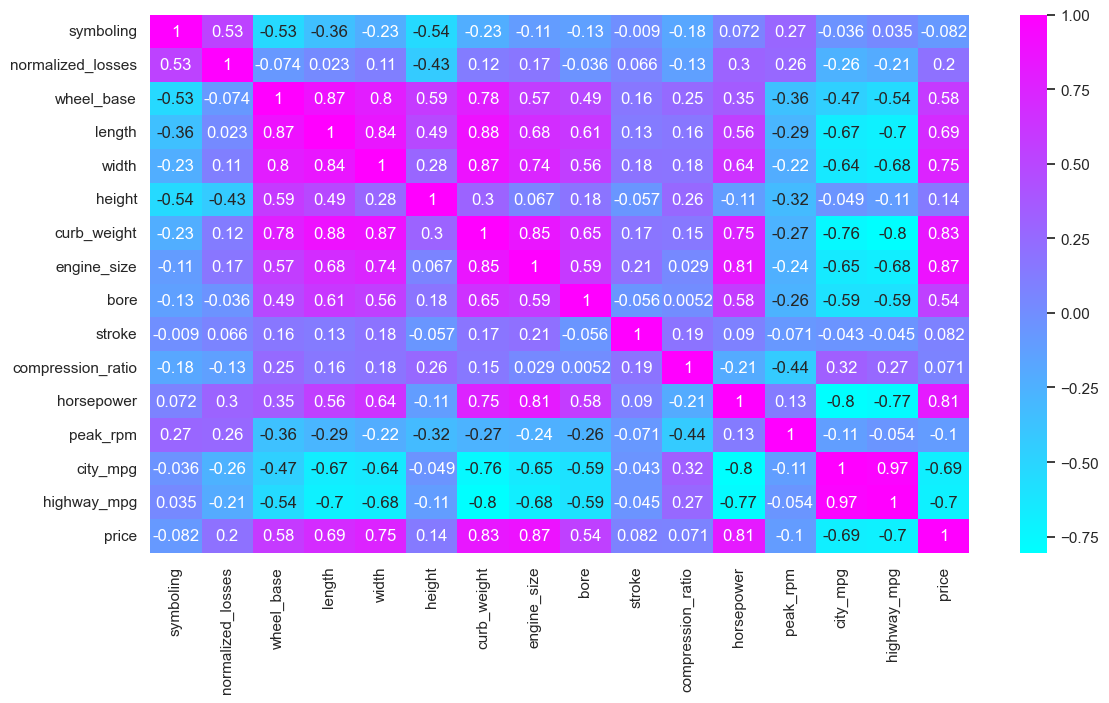

In [24]:
# TODO M2.5: correlation heatmap
numeric_col = df_clean.select_dtypes(['float64', 'int64']).corr()
fig, axes = plt.subplots(figsize=(12, 7.2))
sns.heatmap(numeric_col, ax = axes, annot = True, cmap = 'cool')
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Ta thấy có rất nhiều trường hợp đa cộng tuyến giữa các biến. Ví dụ: biến `width` có correlation $\geq 0.7$ với `wheel_base`, `length`, `curb_weight`, `engine_size` và `price`

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

### `city_mpg` thay đổi như thế nào theo `fuel_system`?

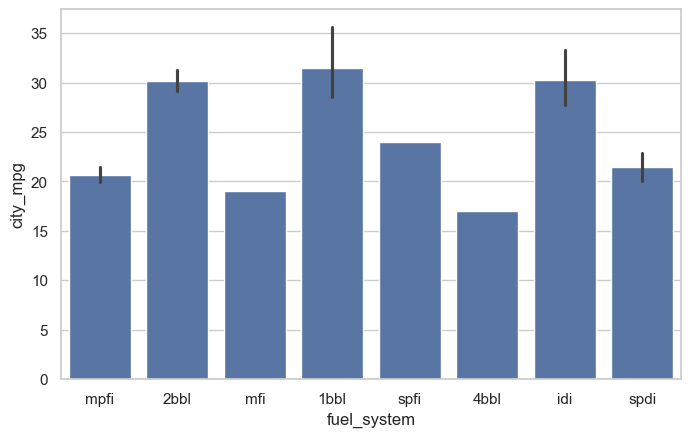

In [25]:
# TODO M2.6: biểu đồ tự chọn
sns.barplot(df_clean, x = 'fuel_system', y = 'city_mpg')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

- Hệ thống 2bbl, 1bbl và idi có mức độ tiết kiệm nhiên liệu trung bình trên 40 mpg (chứng tỏ xe thân thiện với môi trường), trong khi mpfi, mfi và 4bbl thì từ 20 mpg trở xuống.
- Hệ thống 1bbl có đường màu đen dài nhất, chứng tỏ dữ liệu về `city_mpg` của hệ thống phân tán nhiều nhất.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

- Các phát hiện chính có dẫn chứng: 
    * Xuất hiện hai trường hợp đa cộng tuyến giữa một số cặp có chứa biến `width` và `length`.
        * length - (wheel_base, length, curb_weight) có correlation >= 0.7
    * Số lượng mẫu xe kiểu `sedan` và `hatchback` chiếm tỉ lệ đáng kể so với ba mẫu `convertible`, `wagon` và `hardtop`.
        * sedan (khoảng 95), hatchback (khoảng 70)
        * wagon (khoảng 25), convertible & wagon (khoảng 5-10 / nhóm)
    * Có sự tương quan tuyến tính giữa `engine_size` và `price`
        * Khi engine_size tăng thì price có xu hướng tăng một cách tuyến tính.
- Hạn chế:
    * Chỉ có 1 chiếc xe trong hệ thống mfi và spfi $\rightarrow$ mức độ tiết kiệm nhiên liệu trung bình đo được không tin cậy $\rightarrow$ không kết luận được về tính thân thiện với môi trường của xe có hệ thống đó.
    * Thiếu rất nhiều dữ liệu tại cột `normalized_losses`.
    * Có sự chênh lệch rất lớn giữa các giá trị về `price` của nhóm `sedan`.
- Một ví dụ về correlation không đồng nghĩa causation:
    * curb_weight - length có correlation là 0.88 nhưng thực chất sự thay đổi của curb_weight còn phụ thuộc đáng kể vào wheel_base, width, engine_size, horse_power, price (tương quan dương) và city_mpg, highway_mpg (tương quan âm)
- Một câu hỏi nên phân tích tiếp: `city_mpg` và `highway_mpg` thay đổi như thế nào theo những hãng xe?
    * Để xem hãng xe nào sản xuất những mẫu xe thân thiện với môi trường nhất.